# **Experiment Notebook**



In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


Project name = Streaming Churn

Type = Classification

Experiment = 2

<hr>

## B. Experiment Description


experiment_hypothesis: XGBoost will outperform the Random Forest model in churn prediction, particularly in improving recall without sacrificing precision.

experiment_expectations: I expect XGBoost to provide a better balance between precision and recall, resulting in improved F1-score and AUC-ROC, while also reducing the number of missed churners (false negatives).

<hr>

## C. Data Understanding


### C.0 Import Packages

In [2]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Numpy for numerical computing and array operations
import numpy as np

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for data visualization
import seaborn as sns

<hr>

### C.1   Load Datasets

In [3]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [4]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [5]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

<hr>

<hr>

## D. Feature Selection


feature_selection_executive_summary: For this experiment, we maintain the same feature set as in Experiment 1: MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge. This decision allows for a direct comparison with previous models and leverages the established predictive power of these features, while focusing on the impact of the XGBoost algorithm itself in improving churn prediction performance.

> Rationale: For this experiment the selected features will be the same as the last experiment. This is to get a direct comparison with previous models and leverages the established predictive power of these features, while focusing on the impact of the XGBoost algorithm itself in improving churn prediction performance.

In [6]:
#fill the feature list

features_list = ['MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']

> Results: Feature list is created with the five selected features.

<hr>

## E. Data Preparation

data_preparation_executive_summary: The data preparation process for this experiment was limited to the creation of feature datasets (X) containing only the five selected features: MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge. No additional transformations or preprocessing steps were applied at this stage, maintaining the original scale and distribution of these key features for the initial modeling phase. All features selected are numerical so there is no need for encoding.

> Rationale: Creating X datasets with only the selected features ensures that the model focuses on the most predictive variables, potentially reducing noise and improving computational efficiency.

In [7]:
## Create new X dataset with selected features.

X_train = X_train[features_list]
X_val = X_val[features_list]
X_test = X_test[features_list]

> Results: The X datasets now only contain the 5 selected features.

<hr>

## F. Feature Engineering

data_preparation_executive_summary_2: For this experiment, I have decided against creating new features. I want to see the effect of this model compared to Random Forest without the noise of a new feature.

<hr>

## G. Train Machine Learning Model

train_model_executive_summary: In this experiment, XGBoost is implemented using the XGBClassifier from the xgboost library. The model is configured with \'scale_pos_weight\' to address class imbalance, calculated as the ratio of non-churners to churners in the training set. \'logloss\' is used as the evaluation metric and set a random state for reproducibility. The same performance metrics as Experiment 1 (accuracy, precision, recall, F1-score, and AUC-ROC) are employed to evaluate the model, enabling direct comparison with previous experiments. This approach aims to leverage XGBoost\'s advanced features in handling imbalanced datasets and capturing complex patterns, potentially leading to improved churn prediction accuracy and better identification of potential churners.

### G.1 Import Algorithm

> Rationale: XGBoost has the potential to significantly improve the churn prediction model's performance, especially in addressing the challenges of class imbalance and complex feature interactions identified in the previous experiment.

In [8]:
from xgboost import XGBClassifier


<hr>

### G.2 Set Hyperparameters

> Rationale: The model is configured with 'scale_pos_weight' to address class imbalance, calculated as the ratio of non-churners to churners in the training set. 'logloss' is used as the evaluation metric and set a random state for reproducibility.

In [9]:
# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Initialize and train XGBoost model
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

<hr>

### G.3 Fit Model

In [10]:
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:28:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [11]:
y_pred = xgb_model.predict(X_val)
y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]

<hr>

### G.4 Model Technical Performance

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc_roc = roc_auc_score(y_val, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Accuracy: 0.8154
Precision: 0.3919
Recall: 0.0956
F1 Score: 0.1537
AUC-ROC: 0.6723

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      5704
           1       0.39      0.10      0.15      1213

    accuracy                           0.82      6917
   macro avg       0.61      0.53      0.53      6917
weighted avg       0.76      0.82      0.77      6917



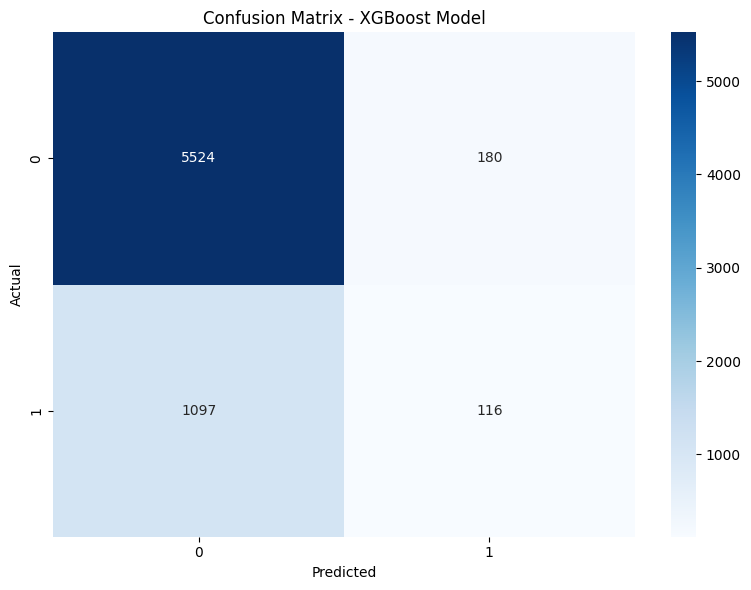

In [13]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


Feature Importances:
                  feature  importance
4              AccountAge    0.314049
3  AverageViewingDuration    0.194319
2     ViewingHoursPerWeek    0.182711
0          MonthlyCharges    0.171970
1            TotalCharges    0.136952


<Figure size 1000x600 with 0 Axes>

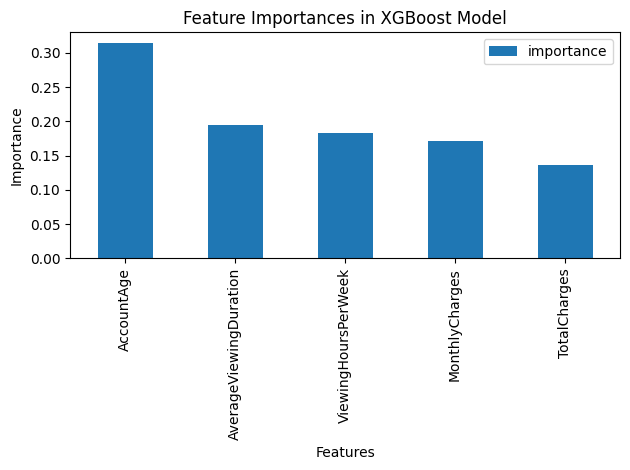

In [14]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance)

# Plot feature importances
plt.figure(figsize=(10, 6))
feature_importance.plot(x='feature', y='importance', kind='bar')
plt.title('Feature Importances in XGBoost Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

> Results: The XGBoost model shows modest improvements over the previous models. It achieves slightly lower accuracy (0.8154) compared to the baseline, but demonstrates improved recall (0.0956) for the churn class, indicating better identification of potential churners. The F1 score (0.1537) and AUC-ROC (0.6723) have also improved, suggesting a better balance between precision and recall. Notably, the model's feature importance ranking differs from the Random Forest, with AccountAge now being the most influential predictor of churn.

<hr>

### G.5 Business Impact from Current Model Performance

In [15]:
from sklearn.metrics import confusion_matrix

def churn_cost_calculation(y_true, y_pred):
    """
    Calculate the cost and benefit of the churn prevention strategy compared to taking no action.

    Parameters:
    y_true (array): True labels (1 for churn, 0 for non-churn)
    y_pred (array): Predicted labels (1 for churn, 0 for non-churn)

    Returns:
    dict: A dictionary containing cost calculations and key metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Constants
    monthly_charge = 12.5  # average monthly charge
    discount_percentage = 0.5  # 50% discount
    discount_duration = 3  # 3 months

    # Scenario 1: Do nothing
    do_nothing_revenue = (tn + fp) * monthly_charge * discount_duration

    # Scenario 2: Apply discount to predicted churners
    discount_revenue = (tn * monthly_charge * discount_duration) + ((tp + fp) * monthly_charge * discount_percentage * discount_duration)

    # Benefit of the strategy
    benefit = discount_revenue - do_nothing_revenue

    return {
        "do_nothing_revenue": round(do_nothing_revenue, 2),
        "discount_revenue": round(discount_revenue, 2),
        "benefit": round(benefit, 2),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    }

# Usage
results = churn_cost_calculation(y_val, y_pred)

print(f"Revenue if do nothing: ${results['do_nothing_revenue']:,.2f}")
print(f"Revenue with discount strategy: ${results['discount_revenue']:,.2f}")
print(f"Benefit of discount strategy: ${results['benefit']:,.2f}")
print(f"True Positives (correctly predicted churners): {results['true_positives']}")
print(f"False Positives (incorrectly predicted churners): {results['false_positives']}")
print(f"False Negatives (missed churners): {results['false_negatives']}")
print(f"True Negatives (correctly predicted non-churners): {results['true_negatives']}")

Revenue if do nothing: $213,900.00
Revenue with discount strategy: $212,700.00
Benefit of discount strategy: $-1,200.00
True Positives (correctly predicted churners): 116
False Positives (incorrectly predicted churners): 180
False Negatives (missed churners): 1097
True Negatives (correctly predicted non-churners): 5524


> Results: The XGBoost model in Experiment 2 shows a slight improvement in identifying potential churners compared to the Random Forest model in Experiment 1, but at the cost of increased false positives. The XGBoost model correctly identified 116 churners (True Positives) compared to 94 in Experiment 1, potentially saving more customers. However, it also incorrectly flagged 180 non-churners (False Positives) versus 138 in Experiment 1, leading to more unnecessary discounts. The net financial impact is marginally worse, with a loss of 1,200 compared to 825 in Experiment 1. While the XGBoost model slightly reduces the number of missed churners (False Negatives) from 1,119 to 1,097, the overall economic benefit remains negative in the short term. This result underscores the challenge of balancing improved churn detection with the cost of false positives in the discount strategy.

<hr>

## H. Experiment Outcomes

final_experiment_outcome = 'Hypothesis Confirmed'

> Key Learnings: XGBoost demonstrated incremental improvements in churn prediction, particularly in recall and F1 score, indicating its potential for handling imbalanced datasets. The shift in feature importance, with AccountAge becoming the most influential predictor, suggests that different algorithms may capture varied aspects of the churn pattern. Despite these improvements, the model still struggles with the critical balance between identifying more churners and maintaining precision, as evidenced by the increased false positives and the still substantial cost of missed churners.

> Recommendations for Next Experiment: Given the current low recall in churn predictions, the next experiment should focus on exploring alternative models before committing to fine-tuning. Two potential algorithms to try are Gradient Boosting and Balanced Random Forest. Gradient Boosting, like XGBoost, can capture complex patterns in the data. Balanced Random Forest is designed to handle imbalanced datasets, which could potentially improve the churn detection without sacrificing overall performance. By testing these models with minimal initial tuning, I can gauge their baseline performance before spending too much time fine tuning them.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0e20096b-eda0-43a0-b83c-e24d084104d6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>